# RQ1 --- Effectiveness

In [1]:
import sys

sys.path.insert(0, "..")
import numpy as np
from experiments._loader import load_all_results, success_only
from experiments._analysis import (
    PALETTE,
    tex,
    setup_matplotlib,
    compute_image_metrics,
    compute_text_metrics,
    classify_termination_series,
    TERMINATION_COLORS,
    TERMINATION_ORDER,
)

import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

setup_matplotlib()

df_all = load_all_results(include_baseline_fail=True)
df_opt = success_only(df_all)

THRESHOLDS = np.arange(0.0, 1.1, 0.1)  # 0.0, 0.1, ..., 0.9

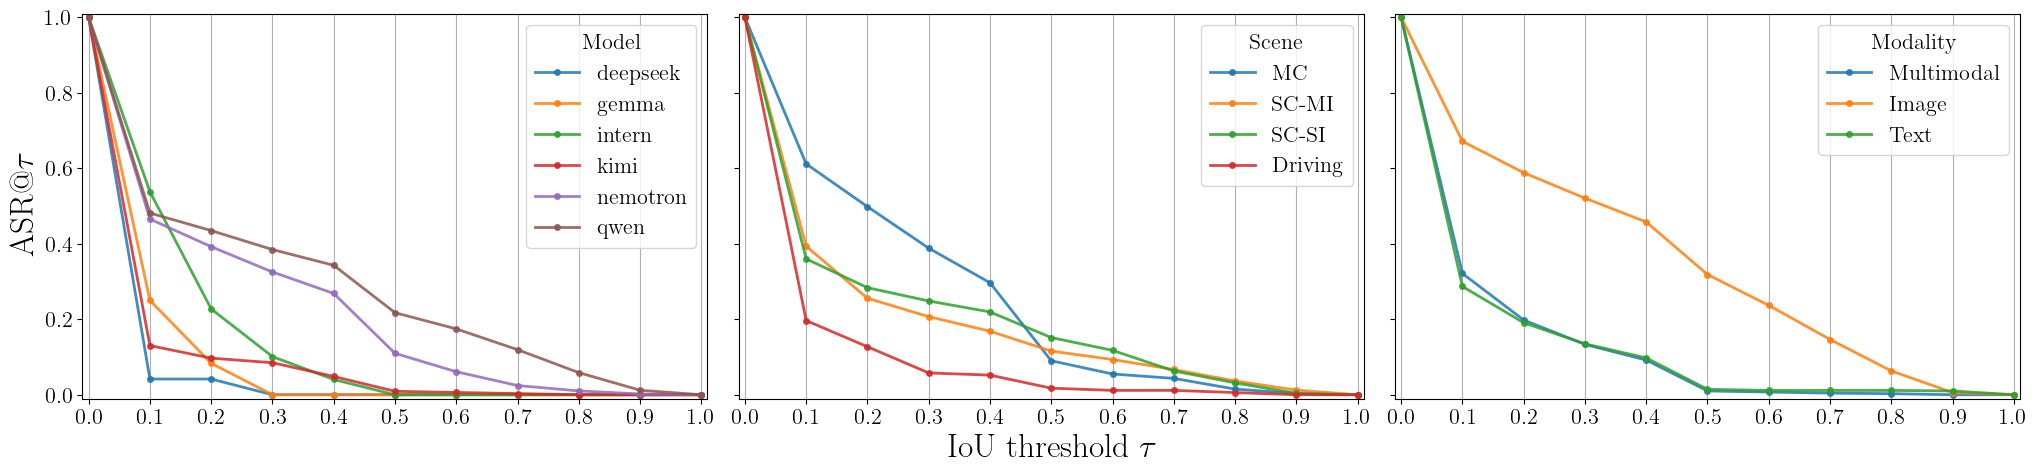

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5), sharey=True)
fig.subplots_adjust(wspace=0.05)

# 1) By model
ax = axes[0]
for i, model in enumerate(sorted(df_opt["model"].unique())):
    sub = df_opt[df_opt["model"] == model]
    if df_opt[df_opt["model"] == model].size < 30:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=tex(model),
        color=PALETTE[i],
        alpha=0.85,
        marker="o",
        markersize=4,
    )
##ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_ylabel(r"ASR@$\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Model")
ax.grid(axis="x")

# 2) By scene
SCENE_ALIAS = {
    "multi": "MC",
    "single/multi": "SC-MI",
    "single/solo": "SC-SI",
    "udacity": "Driving"
}

ax = axes[1]
for scene, label in SCENE_ALIAS.items():
    sub = df_opt[df_opt["obj_category"] == scene]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
ax.set_xlabel(r"IoU threshold $\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Scene")
ax.grid(axis="x")

# 3) By modality
MODALITY_ALIAS = {
    "multi": "Multimodal",
    "image": "Image",
    "text": "Text",
}

ax = axes[2]
for modality, label in MODALITY_ALIAS.items():
    sub = df_opt[df_opt["genome_mode"] == modality]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
# ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Modality")
ax.grid(axis="x")
plt.savefig("figures/curves_rq1.pdf", dpi=200, bbox_inches="tight")

In [8]:
df_opt = compute_image_metrics(df_opt)

df_txt = compute_text_metrics(df_opt[df_opt["genome_mode"].isin(["multi", "text"])].copy())

SCENES = [
    ("MC", "multi"),
    ("SC-MI", "single/multi"),
    ("SC-SI", "single/solo"),
    ("Driving", "udacity"),
]

GENOME_MODES = [
    "multi",
    "image",
    "text",
]


def format_mean_std(
    mean: float,
    std: float,
    decimals: int = 2,
) -> str:
    if pd.isna(mean):
        return "---"

    std = 0.0 if pd.isna(std) else std
    return f"${mean:.{decimals}f} \\pm {std:.{decimals}f}$"


records = []

for model in sorted(df_all["model"].dropna().unique()):
    for scene, obj_category in SCENES:
        scene_all = df_all[(df_all["model"] == model) & (df_all["obj_category"] == obj_category)]

        # Baseline failure rate is shared across the three manipulations.
        fail_rate = (
            (scene_all["status"] == "baseline_fail").mean() if not scene_all.empty else np.nan
        )

        for genome_mode in GENOME_MODES:
            sub_all = scene_all[scene_all["genome_mode"] == genome_mode]

            sub_opt = df_opt[
                (df_opt["model"] == model)
                & (df_opt["genome_mode"] == genome_mode)
                & (df_opt["obj_category"] == obj_category)
            ]

            record = {
                "model": model,
                "scene": scene,
                "genome_mode": genome_mode,
                "fail_rate": f"{fail_rate:.2f}" if not pd.isna(fail_rate) else "---",
                "frac10": "---",
                "frac25": "---",
                "frac50": "---",
                "ssim": "---",
                "ned": "---",
            }

            if not sub_all.empty and fail_rate <= 0.90 and not sub_opt.empty:
                record["frac10"] = f"{(sub_all['final_iou'] <= 0.10).mean():.2f}"
                record["frac25"] = f"{(sub_all['final_iou'] <= 0.25).mean():.2f}"
                record["frac50"] = f"{(sub_all['final_iou'] <= 0.50).mean():.2f}"

                if genome_mode in {"multi", "image"}:
                    ms = sub_opt["ms_ssim"].dropna()

                    if not ms.empty:
                        record["ssim"] = format_mean_std(
                            ms.mean(),
                            ms.std(),
                        )

                if genome_mode in {"multi", "text"}:
                    nd = df_txt[
                        (df_txt["model"] == model)
                        & (df_txt["genome_mode"] == genome_mode)
                        & (df_txt["obj_category"] == obj_category)
                    ]["ned"].dropna()

                    if not nd.empty:
                        record["ned"] = format_mean_std(
                            nd.mean(),
                            nd.std(),
                        )

            records.append(record)

effectiveness_df = pd.DataFrame(records)

/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/numpy/_core/_methods.py:51: ComplexWarning: Casting complex values to real discards the imaginary part
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [9]:
effectiveness_df["fail_rate"] = pd.to_numeric(
    effectiveness_df["fail_rate"],
    errors="coerce",
)

effectiveness_df = effectiveness_df[
    effectiveness_df["fail_rate"] < 0.95
].copy()
effectiveness_df.head()

,model,scene,genome_mode,fail_rate,frac10,frac25,frac50,ssim,ned
9,deepseek,Driving,multi,0.93,---,---,---,---,---
10,deepseek,Driving,image,0.93,---,---,---,---,---
11,deepseek,Driving,text,0.93,---,---,---,---,---
24,intern,MC,multi,0.48,0.37,0.70,1.00,$0.89+0.00j \pm 0.06$,$0.05 \pm 0.11$
25,intern,MC,image,0.48,0.34,0.66,1.00,$0.91+0.00j \pm 0.05$,---


In [11]:
effectiveness_df.to_csv("effectiveness.csv")

<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_3587227/2546217542.py:70: SyntaxWarning: invalid escape sequence '\%'
  f"{item['percentage']:.2f}\%",


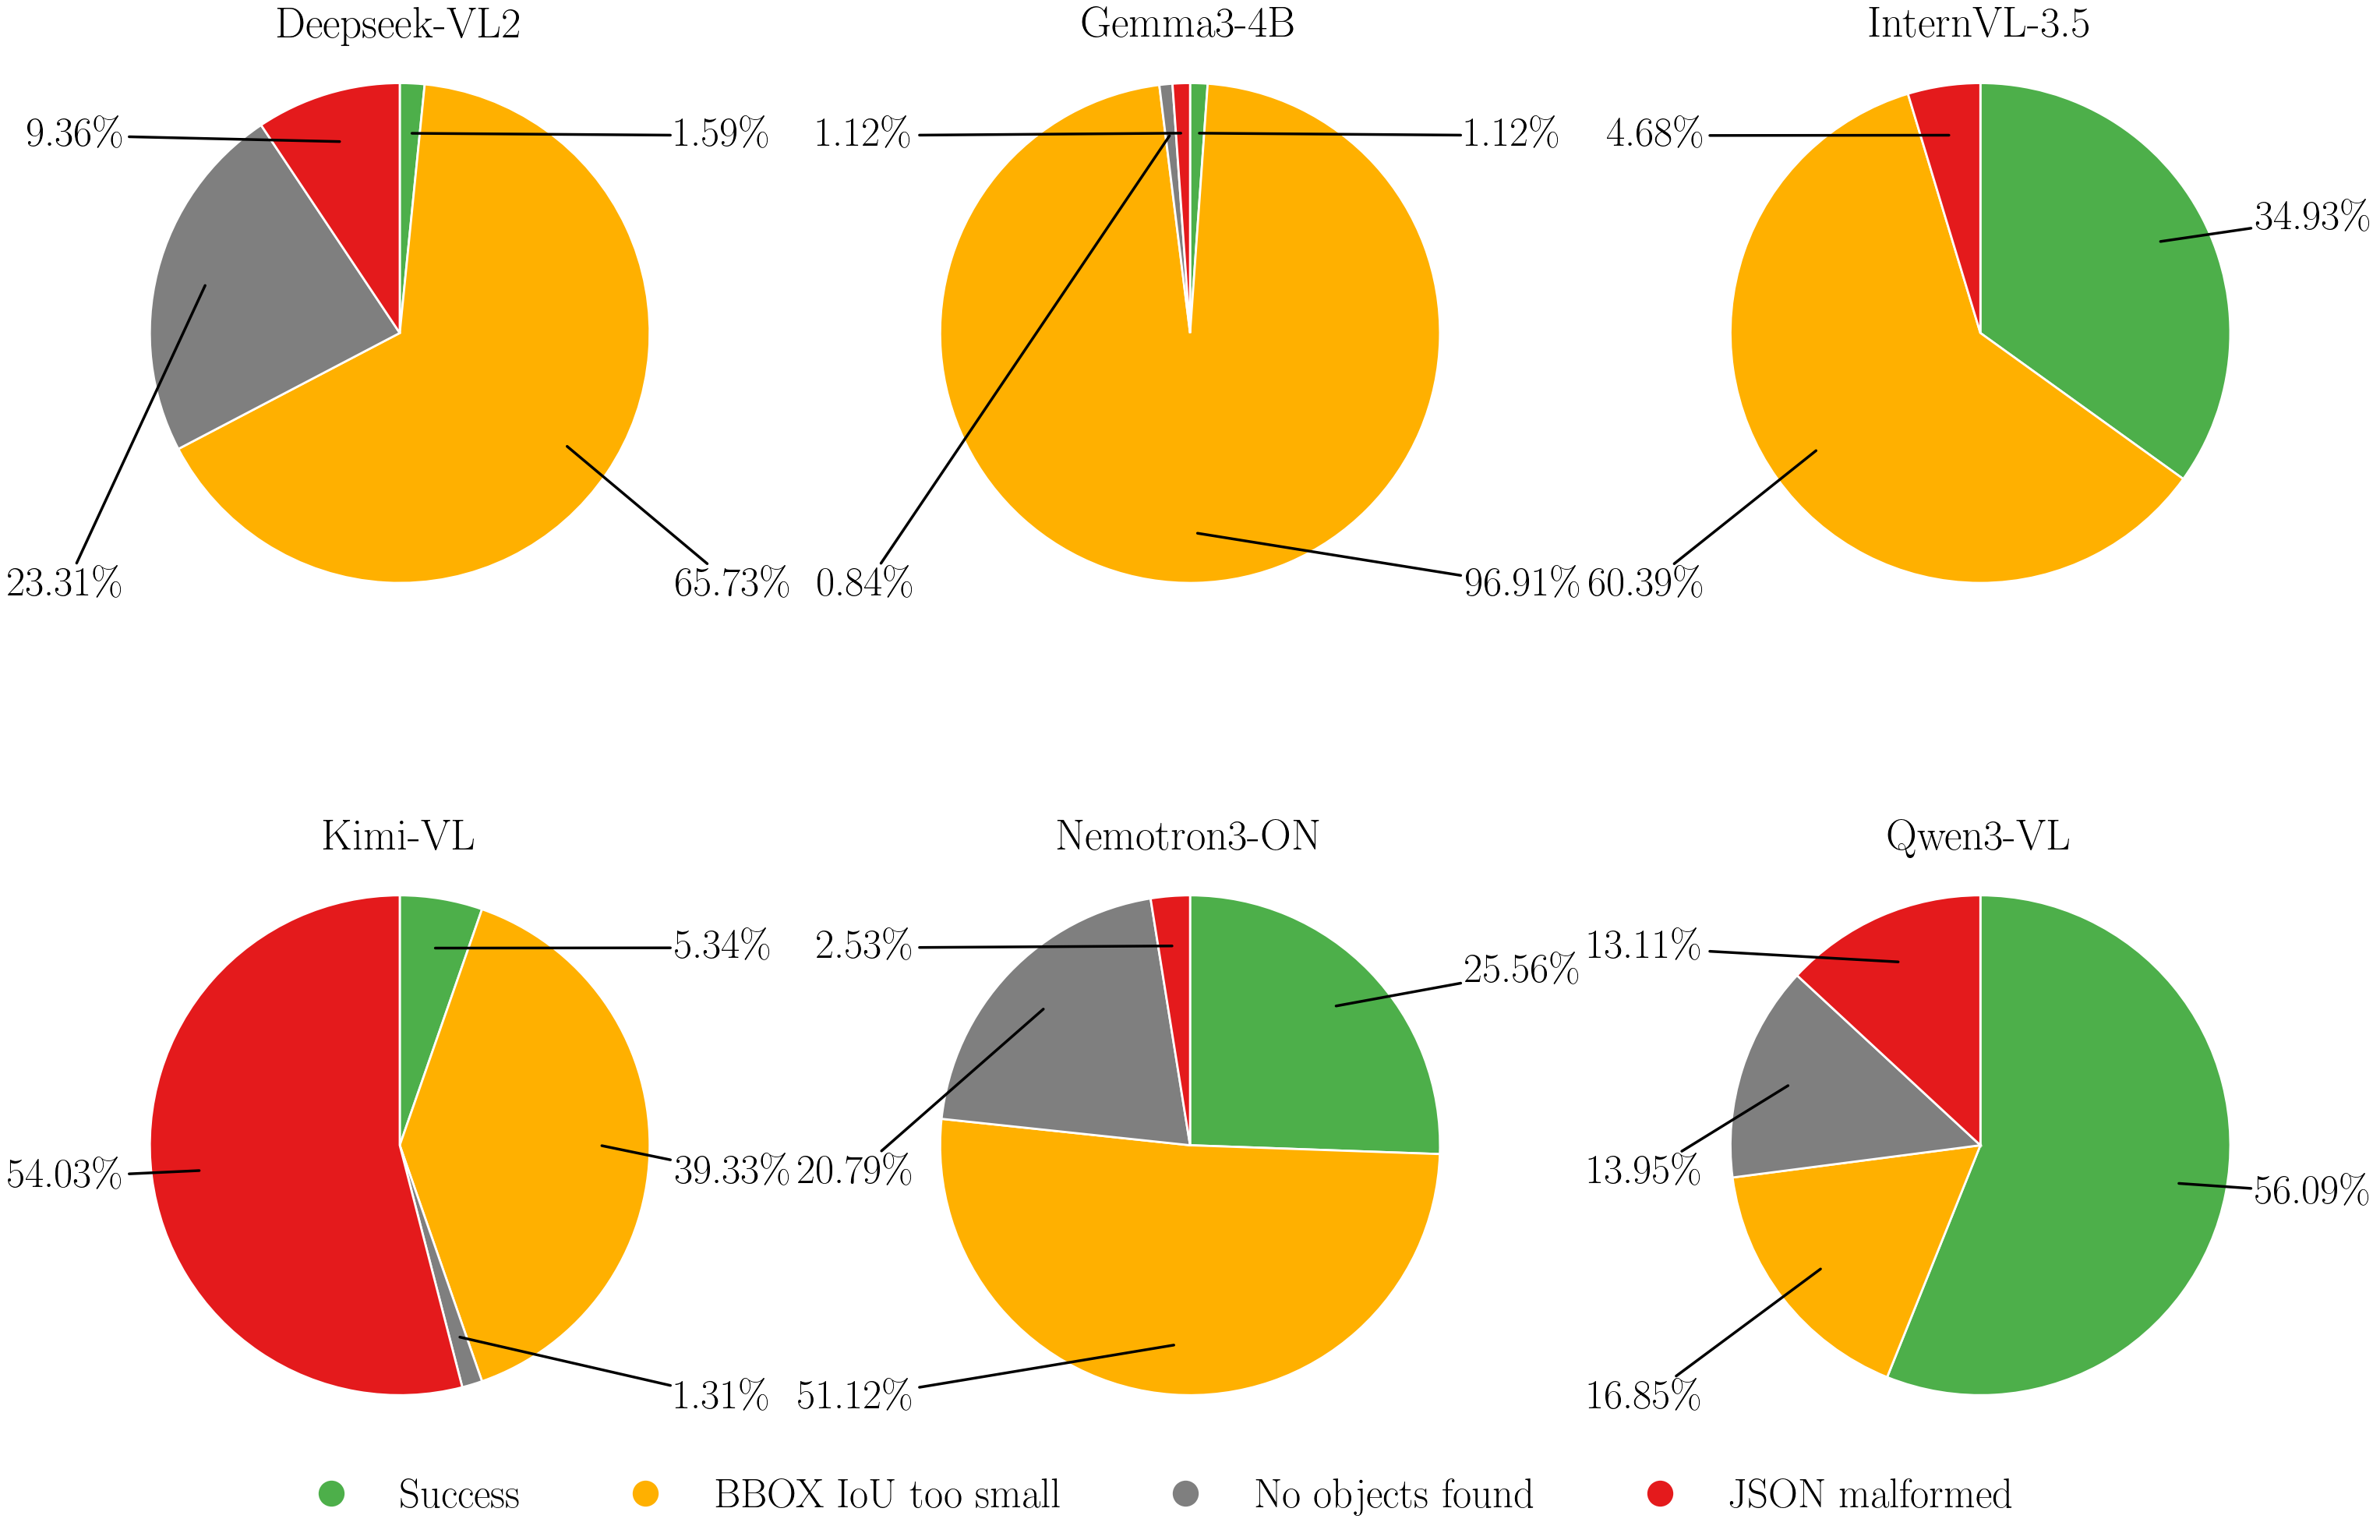

In [6]:
term_df = classify_termination_series(df_all)
models = sorted(term_df["model"].dropna().unique())

TEXT_SIZE = 38
TITLE_SIZE = 40
LEGEND_SIZE = 38


MODEL_LABEL = {
    "qwen": "Qwen3-VL",
    "kimi": "Kimi-VL",
    "intern": "InternVL-3.5",
    "gemma": "Gemma3-4B",
    "deepseek": "Deepseek-VL2",
    "nemotron": "Nemotron3-ON",
}

def add_percentage_callouts(
    ax,
    wedges,
    values,
    *,
    fontsize=TEXT_SIZE,
    min_percentage=0.0,
):
    """Add non-overlapping percentage labels with leader lines."""
    total = sum(values)
    if total <= 0:
        return

    callouts = []

    for wedge, value in zip(wedges, values):
        percentage = 100.0 * value / total
        if percentage <= min_percentage:
            continue

        angle = math.radians((wedge.theta1 + wedge.theta2) / 2.0)
        x = math.cos(angle)
        y = math.sin(angle)

        callouts.append(
            {
                "percentage": percentage,
                "anchor": (0.8 * x, 0.8 * y),
                "side": 1 if x >= 0 else -1,
                "natural_y": y,
            }
        )

    for side in (-1, 1):
        side_callouts = [item for item in callouts if item["side"] == side]
        side_callouts.sort(key=lambda item: item["natural_y"])

        count = len(side_callouts)
        if count == 0:
            continue

        # Spread labels vertically so they cannot overlap.
        if count == 1:
            label_positions = [side_callouts[0]["natural_y"]]
        else:
            label_positions = [-1.01 + i * (1.8 / (count - 1)) for i in range(count)]

        text_x = 1.1 * side
        horizontal_alignment = "left" if side > 0 else "right"

        for item, text_y in zip(side_callouts, label_positions):
            ax.annotate(
                f"{item['percentage']:.2f}\%",
                xy=item["anchor"],
                xytext=(text_x, text_y),
                ha=horizontal_alignment,
                va="center",
                fontsize=fontsize,
                arrowprops={
                    "arrowstyle": "-",
                    "linewidth": 2.5,
                },
            )


ncols = math.ceil(len(models) / 2)

fig, axes = plt.subplots(
    2,
    ncols,
    figsize=(13 * ncols, 24),
    squeeze=False,
)

axes = axes.ravel()

for ax, model in zip(axes, models):
    sub = term_df[term_df["model"] == model]
    counts = sub["termination_type"].value_counts()

    labels = [label for label in TERMINATION_ORDER if counts.get(label, 0) > 0]
    values = [int(counts[label]) for label in labels]
    colors = [TERMINATION_COLORS[label] for label in labels]

    wedges, _ = ax.pie(
        values,
        colors=colors,
        startangle=90,
        counterclock=False,
        radius=1.0,
        wedgeprops={
            "linewidth": 2,
            "edgecolor": "white",
        },
    )

    add_percentage_callouts(
        ax,
        wedges,
        values,
        fontsize=TEXT_SIZE,
    )

    ax.set_title(
        tex(MODEL_LABEL[model]),
        fontsize=TITLE_SIZE,
        pad=42,
    )

    # Leave room around each pie for the external labels.
    ax.set_xlim(-1.55, 1.55)
    ax.set_ylim(-1., 1.)
    ax.set_aspect("equal")

for ax in axes[len(models) :]:
    ax.axis("off")

present_labels = set(term_df["termination_type"].dropna())

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=TERMINATION_COLORS[label],
        markeredgecolor="none",
        markersize=24,
        label=label,
    )
    for label in TERMINATION_ORDER
    if label in present_labels
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=min(len(legend_handles), 4),
    fontsize=LEGEND_SIZE,
    frameon=False,
    columnspacing=2.0,
    handletextpad=0.7,
    bbox_to_anchor=(0.5, 0.015),
)

fig.subplots_adjust(
    bottom=0.02,
    hspace=0.02,
    wspace=0.02,
)

plt.savefig(
    "figures/pies.png",
    dpi=200,
    bbox_inches="tight",
)